## Required Library

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings

from sklearn.ensemble import (
    HistGradientBoostingRegressor,   # XGBoost-equivalent
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')


### SECTION 2 — DATA LOAD, PREPROCESSING 

In [3]:
df = pd.read_csv('project_power.csv')
df.columns = ['start_utc', 'end_utc', 'consumption_mwh']
df['start_utc'] = pd.to_datetime(df['start_utc'], format='%d-%m-%Y %H:%M')
df = df.sort_values('start_utc').drop_duplicates('start_utc').reset_index(drop=True)
print(f"  Loaded: {len(df):,} rows  |  {df['start_utc'].min().date()} → {df['start_utc'].max().date()}")

# ── Audit-proof split FIRST, then fill WITHIN each half ─────────
SPLIT_DATE = pd.Timestamp('2021-10-01')

def reindex_fill(part):
    rng  = pd.date_range(start=part['start_utc'].min(),
                          end=part['start_utc'].max(), freq='h')
    part = (part.set_index('start_utc')['consumption_mwh']
                .reindex(rng).rename_axis('start_utc').reset_index())
    part['consumption_mwh'] = part['consumption_mwh'].ffill()
    return part

raw_train = reindex_fill(df[df['start_utc'] <  SPLIT_DATE].copy())
raw_test  = reindex_fill(df[df['start_utc'] >= SPLIT_DATE].copy())


  Loaded: 52,966 rows  |  2015-12-31 → 2021-12-31


#### FEATURE ENGINEERING

In [4]:

# ── Feature engineering (shift(1) everywhere — no leakage) ──────
def build_features(p):
    p = p.copy()
    p['hour']       = p['start_utc'].dt.hour
    p['dayofweek']  = p['start_utc'].dt.dayofweek
    p['month']      = p['start_utc'].dt.month
    p['year']       = p['start_utc'].dt.year
    p['quarter']    = p['start_utc'].dt.quarter
    p['dayofyear']  = p['start_utc'].dt.dayofyear
    p['weekofyear'] = p['start_utc'].dt.isocalendar().week.astype(int)
    p['is_weekend'] = (p['dayofweek'] >= 5).astype(int)
    p['hour_sin']   = np.sin(2 * np.pi * p['hour']      / 24)
    p['hour_cos']   = np.cos(2 * np.pi * p['hour']      / 24)
    p['month_sin']  = np.sin(2 * np.pi * p['month']     / 12)
    p['month_cos']  = np.cos(2 * np.pi * p['month']     / 12)
    p['dow_sin']    = np.sin(2 * np.pi * p['dayofweek'] /  7)
    p['dow_cos']    = np.cos(2 * np.pi * p['dayofweek'] /  7)
    p['lag_24']     = p['consumption_mwh'].shift(24)
    p['lag_48']     = p['consumption_mwh'].shift(48)
    p['lag_168']    = p['consumption_mwh'].shift(168)
    p['rolling_mean_24']  = p['consumption_mwh'].shift(1).rolling(24).mean()
    p['rolling_std_24']   = p['consumption_mwh'].shift(1).rolling(24).std()
    p['rolling_mean_168'] = p['consumption_mwh'].shift(1).rolling(168).mean()
    return p.dropna().reset_index(drop=True)

train_fe = build_features(raw_train)
test_fe  = build_features(raw_test)

FEATURES = [
    'hour','dayofweek','month','year','quarter','dayofyear','weekofyear','is_weekend',
    'lag_24','lag_48','lag_168',
    'rolling_mean_24','rolling_std_24','rolling_mean_168',
    'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos'
]


#### VIZ 8 — FEATURE IMPORTANCE COMPARISON

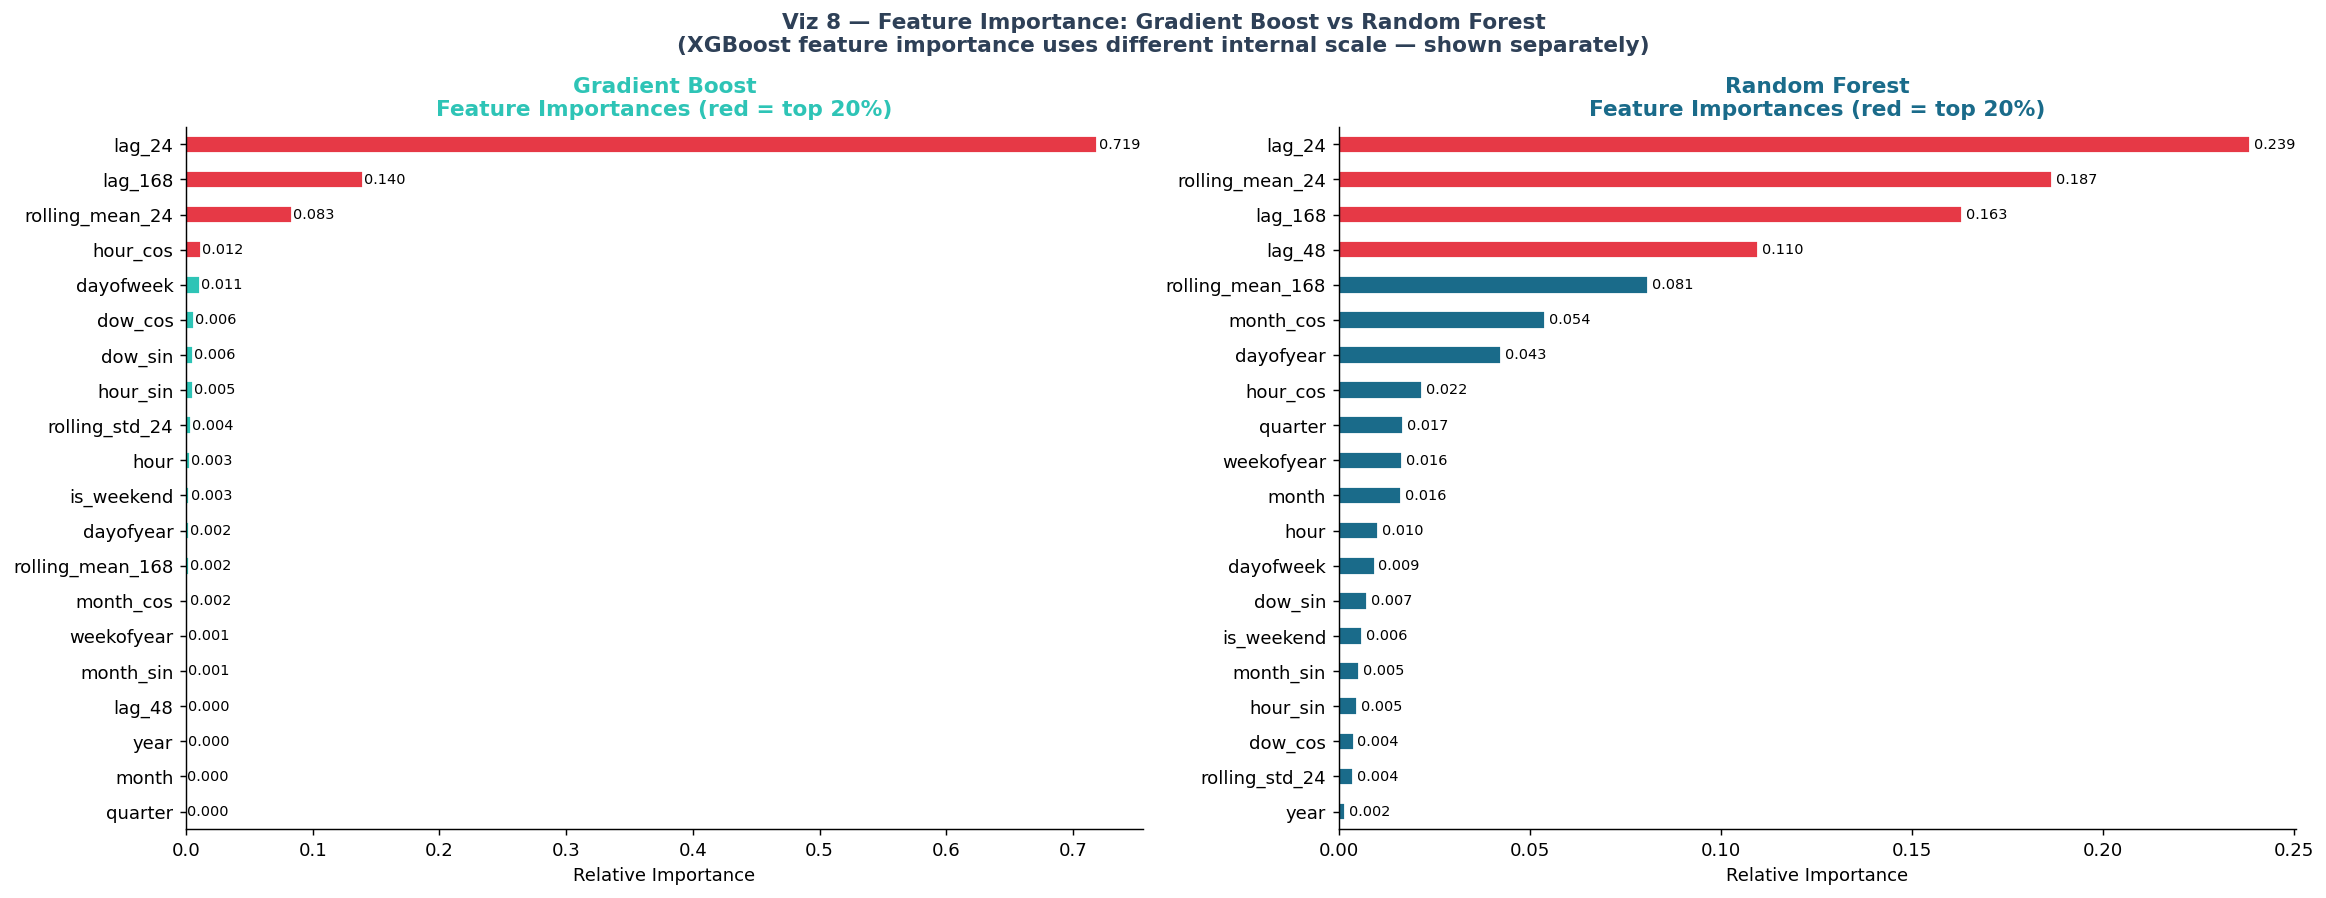

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Viz 8 — Feature Importance: Gradient Boost vs Random Forest\n"
             "(XGBoost feature importance uses different internal scale — shown separately)",
             fontsize=12, fontweight='bold', color='#2E4057')

for ax, name in zip(axes, ['Gradient Boost', 'Random Forest']):
    m = results[name]['model']
    fi = pd.Series(m.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_fi = ['#E63946' if fi.values[i] >= fi.quantile(0.8) else COLORS[name]
                 for i in range(len(fi))]
    fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.set_title(f'{name}\nFeature Importances (red = top 20%)',
                 fontweight='bold', color=COLORS[name])
    ax.set_xlabel("Relative Importance")
    for i, v in enumerate(fi.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()



#### Machine Learning

In [5]:
TARGET = 'consumption_mwh'
assert TARGET not in FEATURES

X_train, y_train = train_fe[FEATURES], train_fe[TARGET]
X_test,  y_test  = test_fe[FEATURES],  test_fe[TARGET]

print(f"  Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"  Features: {len(FEATURES)}  |  Target: {TARGET}\n")


  Train: 50,235 rows  |  Test: 2,037 rows
  Features: 20  |  Target: consumption_mwh



#### SECTION 3 — DEFINE & JUSTIFY ALL 3 MODELS

In [6]:

# Consistent colours per model (used in EVERY chart)
COLORS = {
    'XGBoost':          '#E63946',   # red
    'Random Forest':    '#1A6B8A',   # blue
    'Gradient Boost':   '#2EC4B6',   # teal
}
MODEL_ORDER = ['XGBoost', 'Random Forest', 'Gradient Boost']


models = {
    'XGBoost': HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=42,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=5,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42,
    ),
    'Gradient Boost': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=42,
    ),
}


#### SECTION 4 — TRAIN ALL 3 MODELS

In [7]:

results = {}
for name, model in models.items():
    print(f"  Training {name}...", end=' ', flush=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100
    results[name] = dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, preds=preds, model=model)
    print(f"done  MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.4f}  MAPE={mape:.2f}%")


winner = min(results, key=lambda k: results[k]['MAPE'])
print(f"\n WINNER (lowest MAPE): {winner}\n")



  Training XGBoost... done  MAE=204.4  RMSE=266.8  R²=0.9640  MAPE=1.92%
done  MAE=319.7  RMSE=415.6  R²=0.9127  MAPE=2.88%
done  MAE=219.8  RMSE=289.2  R²=0.9577  MAPE=2.06%

 WINNER (lowest MAPE): XGBoost



#### SECTION 5 — RESULTS TABLE

In [8]:

print(f"  {'Model':<20} {'MAE':>9} {'RMSE':>9} {'R²':>8} {'MAPE%':>8}  RANK")
ranked = sorted(results.items(), key=lambda x: x[1]['MAPE'])
for rank, (name, m) in enumerate(ranked, 1):
    medal = ["1","2","3"][rank-1]
    print(f"  {name:<20} {m['MAE']:>9.2f} {m['RMSE']:>9.2f} {m['R2']:>8.4f} {m['MAPE']:>8.2f}%  {medal}")
print("─" * 65)

  Model                      MAE      RMSE       R²    MAPE%  RANK
  XGBoost                 204.44    266.79   0.9640     1.92%  1
  Gradient Boost          219.83    289.18   0.9577     2.06%  2
  Random Forest           319.75    415.59   0.9127     2.88%  3
─────────────────────────────────────────────────────────────────


#### VIZ 1 — METRIC COMPARISON BAR CHARTS (2×2 grid)

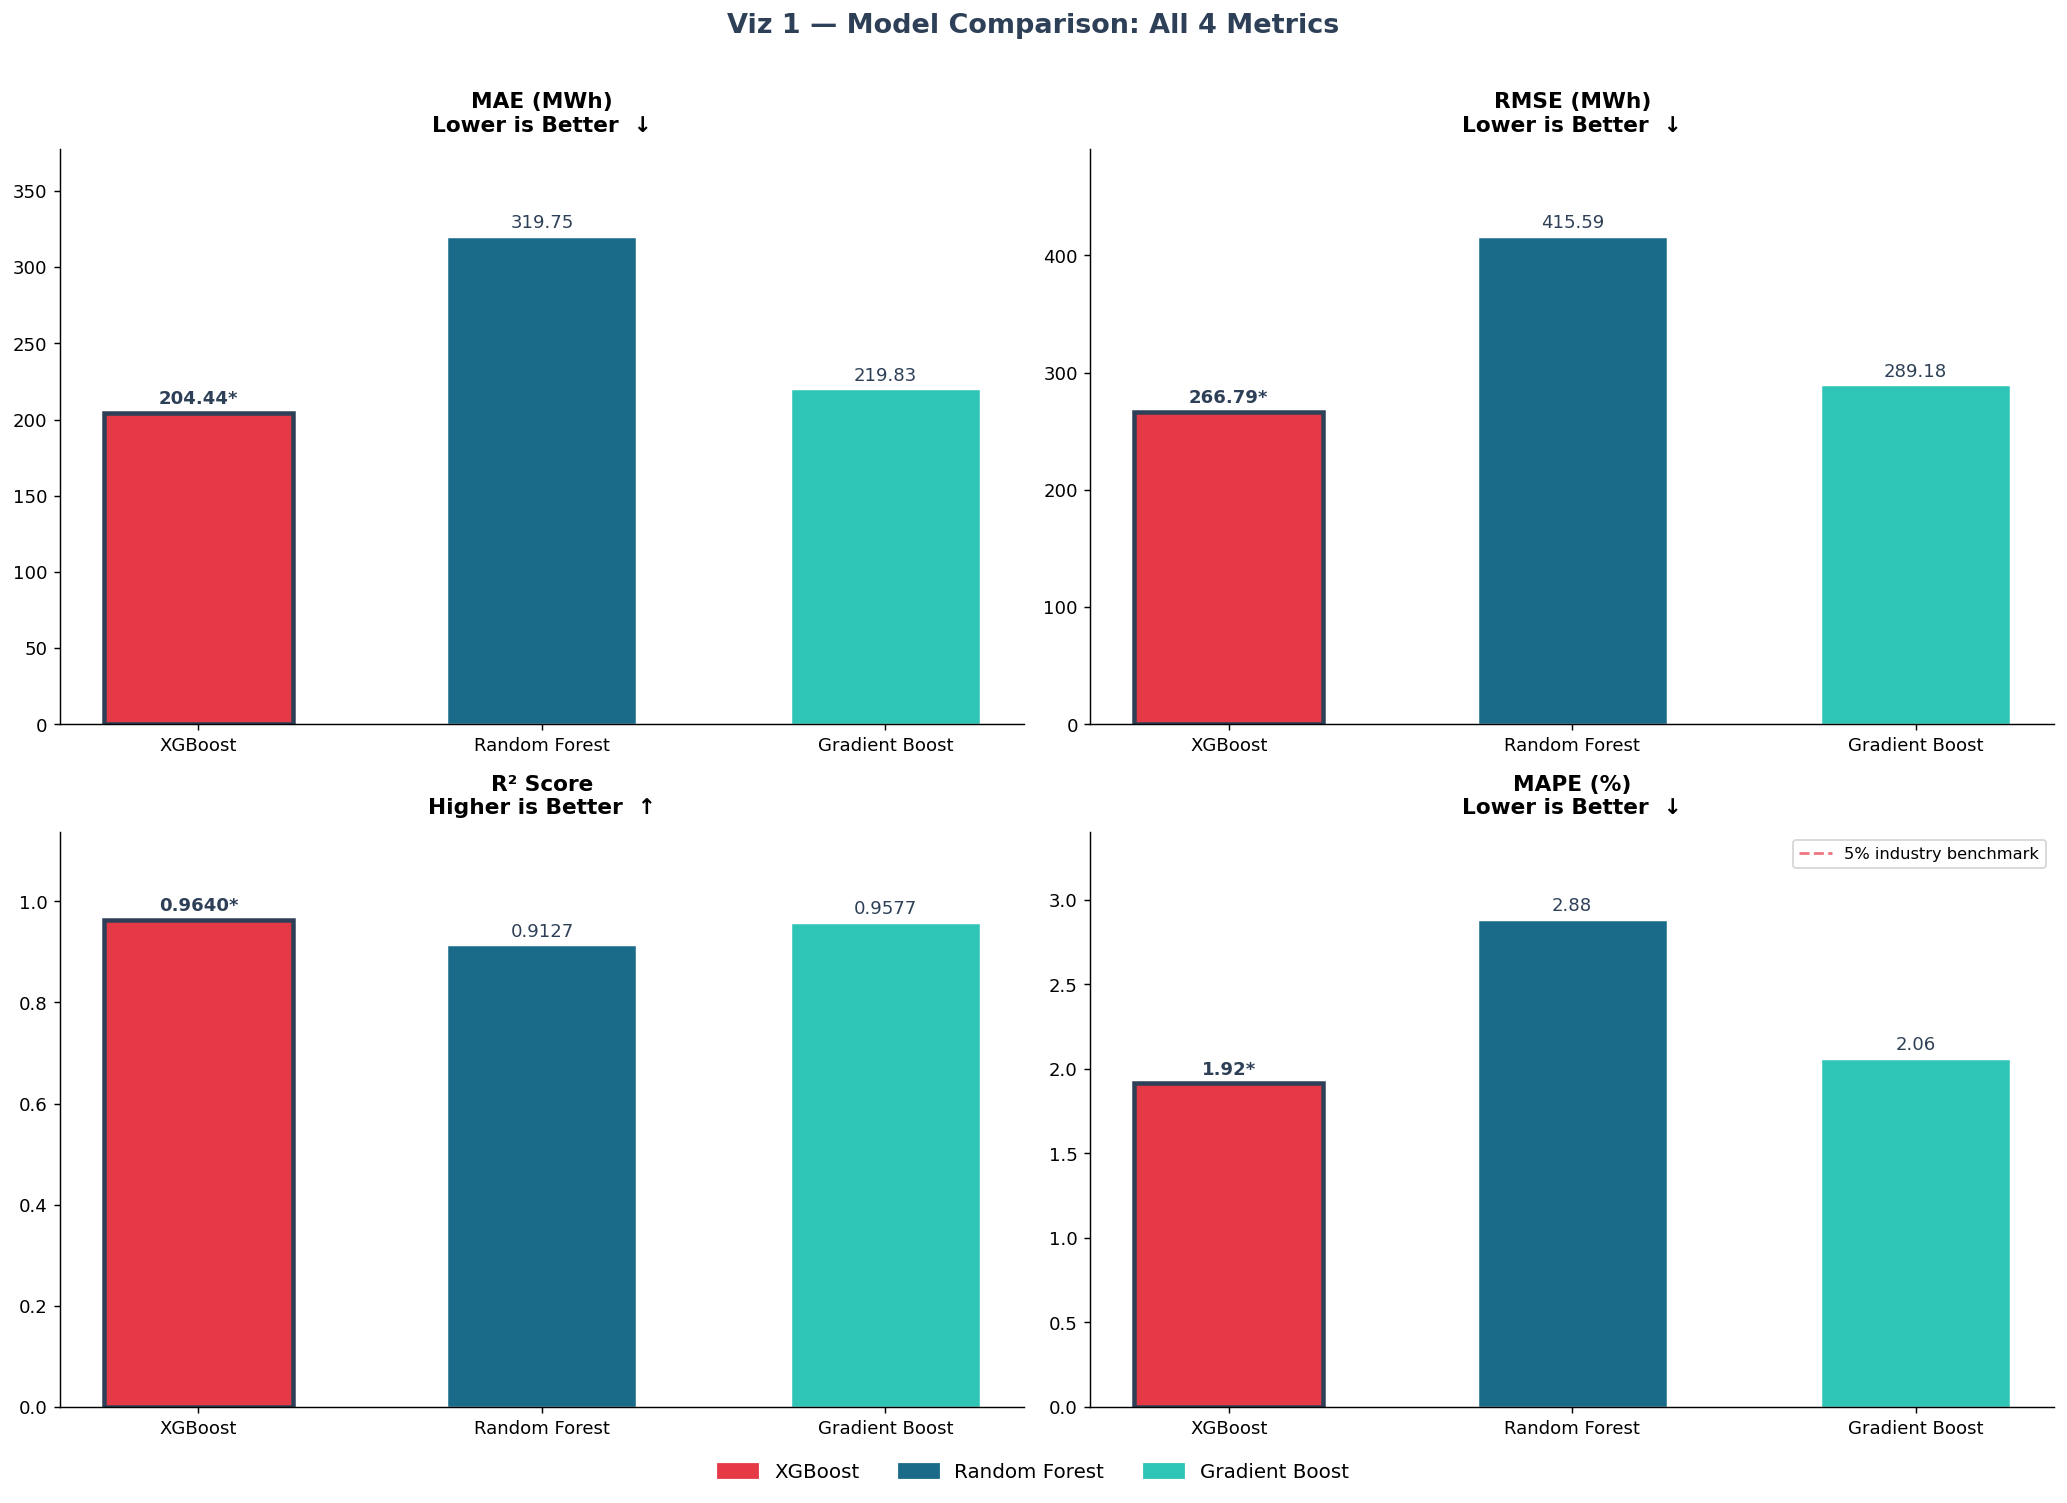

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Viz 1 — Model Comparison: All 4 Metrics",
             fontsize=15, fontweight='bold', color='#2E4057', y=1.01)

metrics = [
    ('MAE',  'MAE (MWh)\nLower is Better  ↓',  True),
    ('RMSE', 'RMSE (MWh)\nLower is Better  ↓', True),
    ('R2',   'R² Score\nHigher is Better  ↑',   False),
    ('MAPE', 'MAPE (%)\nLower is Better  ↓',    True),
]

for ax, (key, title, low_good) in zip(axes.flat, metrics):
    vals  = [results[n][key] for n in MODEL_ORDER]
    bars  = ax.bar(MODEL_ORDER, vals,
                   color=[COLORS[n] for n in MODEL_ORDER],
                   edgecolor='white', linewidth=0.8, width=0.55)

    # Highlight winner with gold star
    best_idx = vals.index(min(vals) if low_good else max(vals))
    for i, (bar, val) in enumerate(zip(bars, vals)):
        label = f'{val:.4f}' if key == 'R2' else f'{val:.2f}'
        star  = '*' if i == best_idx else ''
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                label + star,
                ha='center', va='bottom', fontsize=10,
                fontweight='bold' if i == best_idx else 'normal',
                color='#2E4057')

    # Shade winner bar differently
    bars[best_idx].set_edgecolor('#2E4057')
    bars[best_idx].set_linewidth(2.5)

    ax.set_title(title, fontweight='bold', pad=10)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylim(0, max(vals) * 1.18)

    # Add benchmark line for MAPE
    if key == 'MAPE':
        ax.axhline(5, color='#E63946', lw=1.5, ls='--', alpha=0.7,
                   label='5% industry benchmark')
        ax.legend(fontsize=9)

# Legend
patches = [mpatches.Patch(color=COLORS[n], label=n) for n in MODEL_ORDER]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
#plt.savefig('viz1_metric_comparison.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz1_metric_comparison.png\n")


##### VIZ 3 — PREDICTED vs ACTUAL (all 3 models, 2-week window)

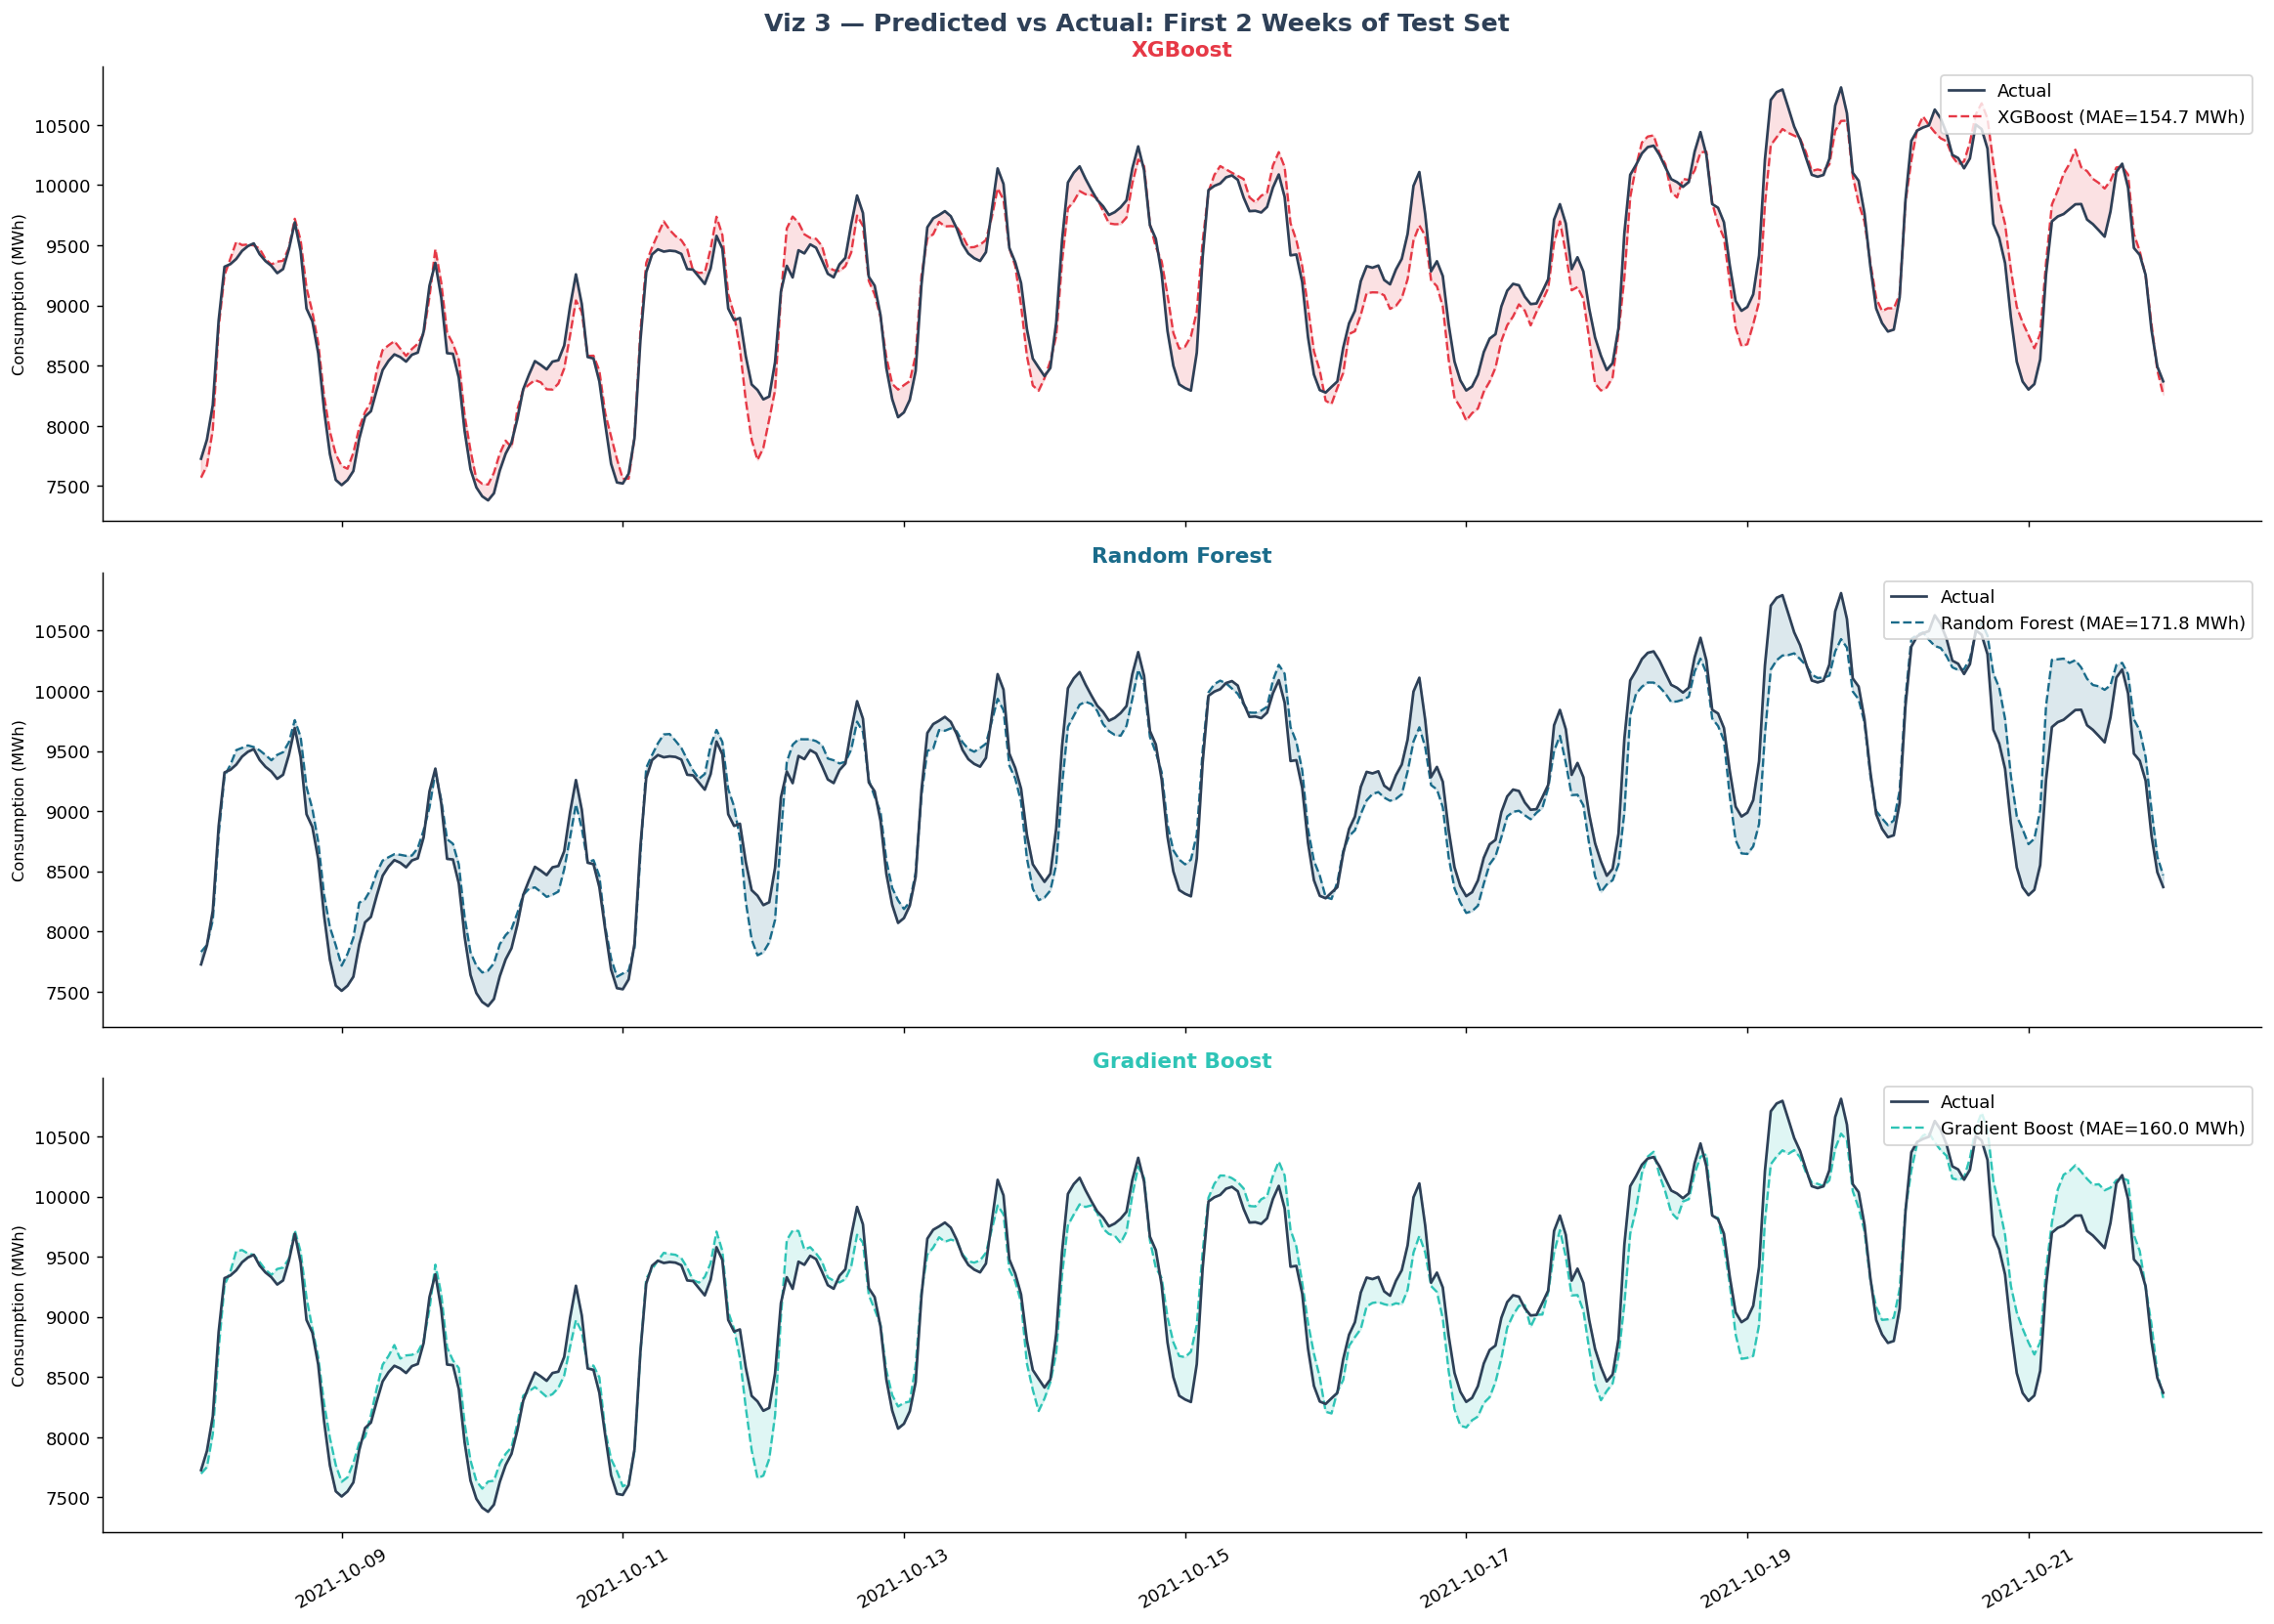

In [10]:
two_weeks = test_fe.head(24 * 14).copy().reset_index(drop=True)
actual    = two_weeks[TARGET].values

fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True)
fig.suptitle("Viz 3 — Predicted vs Actual: First 2 Weeks of Test Set",
             fontsize=14, fontweight='bold', color='#2E4057')

for ax, name in zip(axes, MODEL_ORDER):
    preds_2w = results[name]['preds'][:len(two_weeks)]
    mae_2w   = mean_absolute_error(actual, preds_2w)

    ax.plot(two_weeks['start_utc'], actual, color='#2E4057',
            lw=1.5, label='Actual', zorder=3)
    ax.plot(two_weeks['start_utc'], preds_2w,
            color=COLORS[name], lw=1.3, ls='--',
            label=f'{name} (MAE={mae_2w:.1f} MWh)', zorder=2)
    ax.fill_between(two_weeks['start_utc'], actual, preds_2w,
                    alpha=0.15, color=COLORS[name])
    ax.set_ylabel('Consumption (MWh)', fontsize=9)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(name, fontweight='bold', color=COLORS[name])

axes[-1].tick_params(axis='x', rotation=30)
plt.tight_layout()
#plt.savefig('viz3_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz3_actual_vs_predicted.png\n")


#### VIZ 4 — RESIDUALS (ERROR) DISTRIBUTION

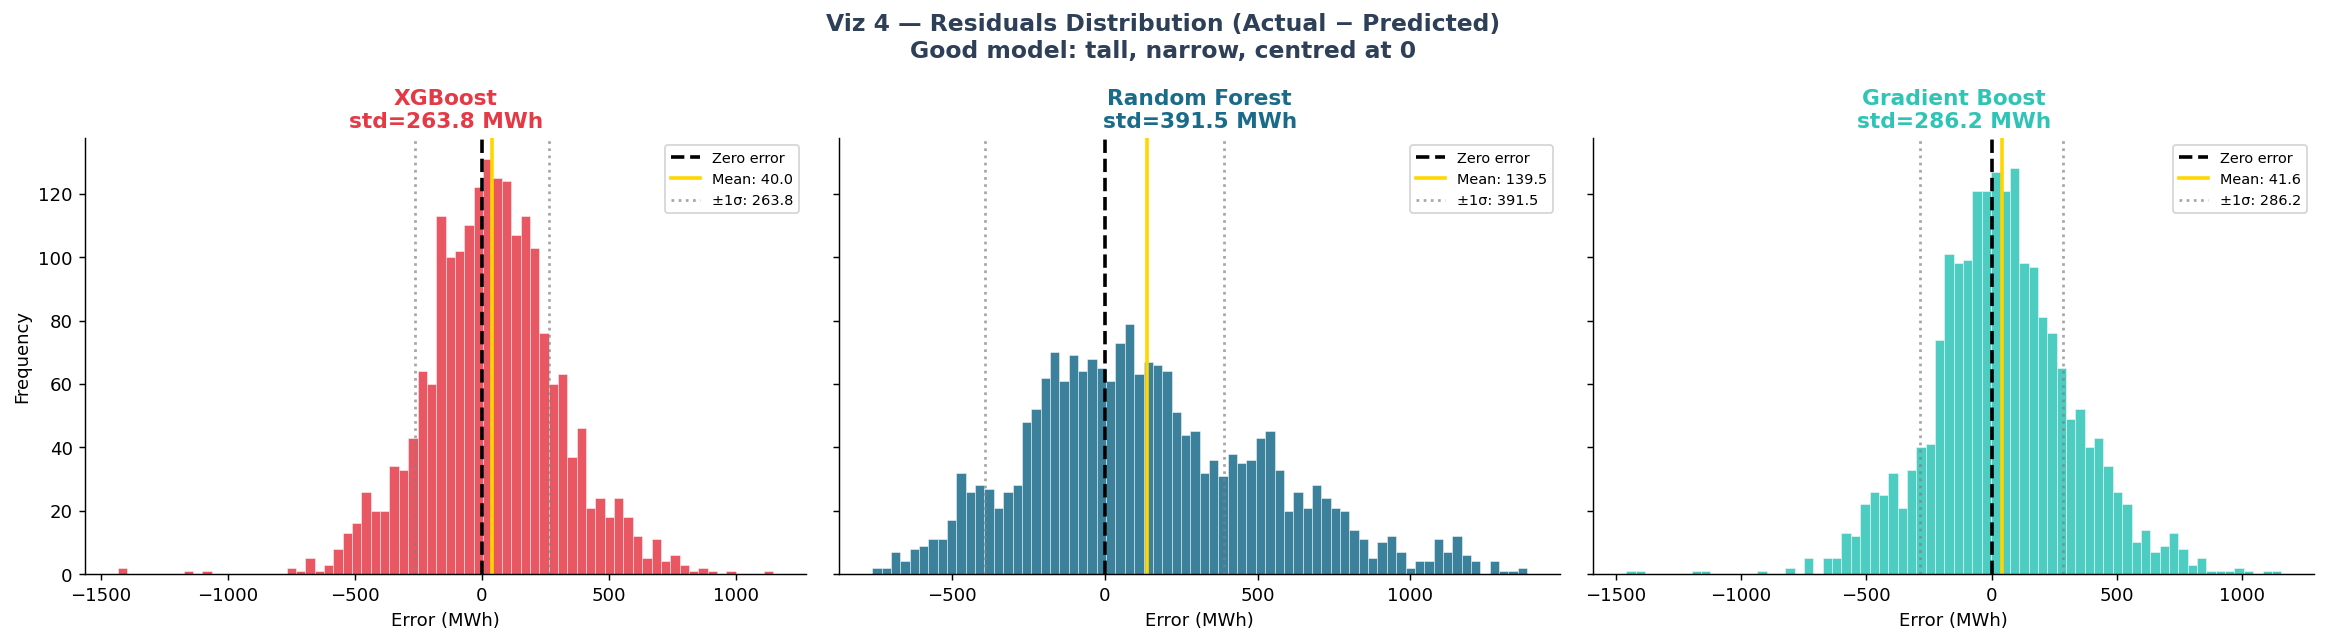

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Viz 4 — Residuals Distribution (Actual − Predicted)\n"
             "Good model: tall, narrow, centred at 0",
             fontsize=13, fontweight='bold', color='#2E4057')

for ax, name in zip(axes, MODEL_ORDER):
    errors = y_test.values - results[name]['preds']
    ax.hist(errors, bins=70, color=COLORS[name],
            edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(0,            color='black', lw=2,   ls='--', label='Zero error')
    ax.axvline(errors.mean(), color='gold', lw=2,   ls='-',
               label=f'Mean: {errors.mean():.1f}')
    ax.axvline( errors.std(), color='grey', lw=1.5, ls=':', alpha=0.7,
               label=f'±1σ: {errors.std():.1f}')
    ax.axvline(-errors.std(), color='grey', lw=1.5, ls=':', alpha=0.7)
    ax.set_title(f'{name}\nstd={errors.std():.1f} MWh',
                 fontweight='bold', color=COLORS[name])
    ax.set_xlabel('Error (MWh)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frequency')
plt.tight_layout()
#plt.savefig('viz4_residuals.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz4_residuals.png\n")



#### VIZ 5 — SCATTER: ACTUAL vs PREDICTED

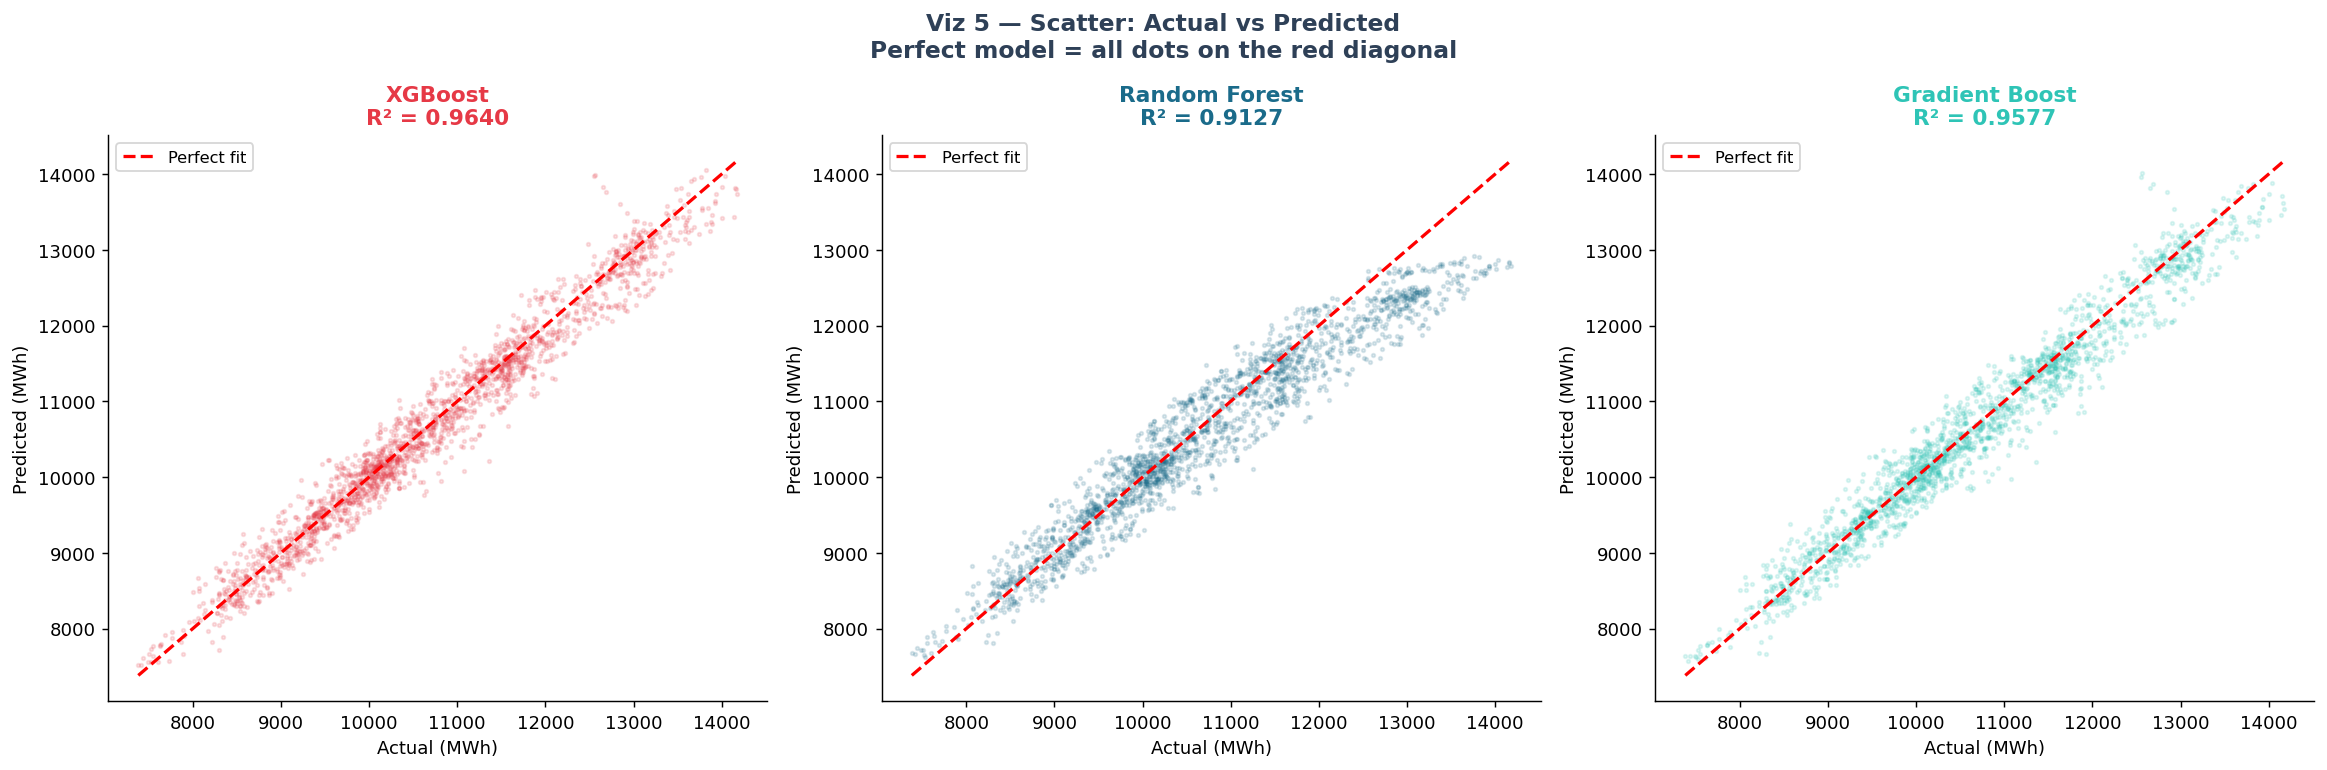

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Viz 5 — Scatter: Actual vs Predicted\n"
             "Perfect model = all dots on the red diagonal",
             fontsize=13, fontweight='bold', color='#2E4057')

for ax, name in zip(axes, MODEL_ORDER):
    preds = results[name]['preds']
    r2    = results[name]['R2']
    lo    = min(y_test.min(), preds.min())
    hi    = max(y_test.max(), preds.max())
    ax.scatter(y_test, preds, alpha=0.15, s=4, color=COLORS[name])
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.8, label='Perfect fit')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', color=COLORS[name])
    ax.set_xlabel('Actual (MWh)')
    ax.set_ylabel('Predicted (MWh)')
    ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('viz5_scatter.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz5_scatter.png\n")



#### VIZ 6 — ERROR BY HOUR OF DAY (all 3 models side-by-side)

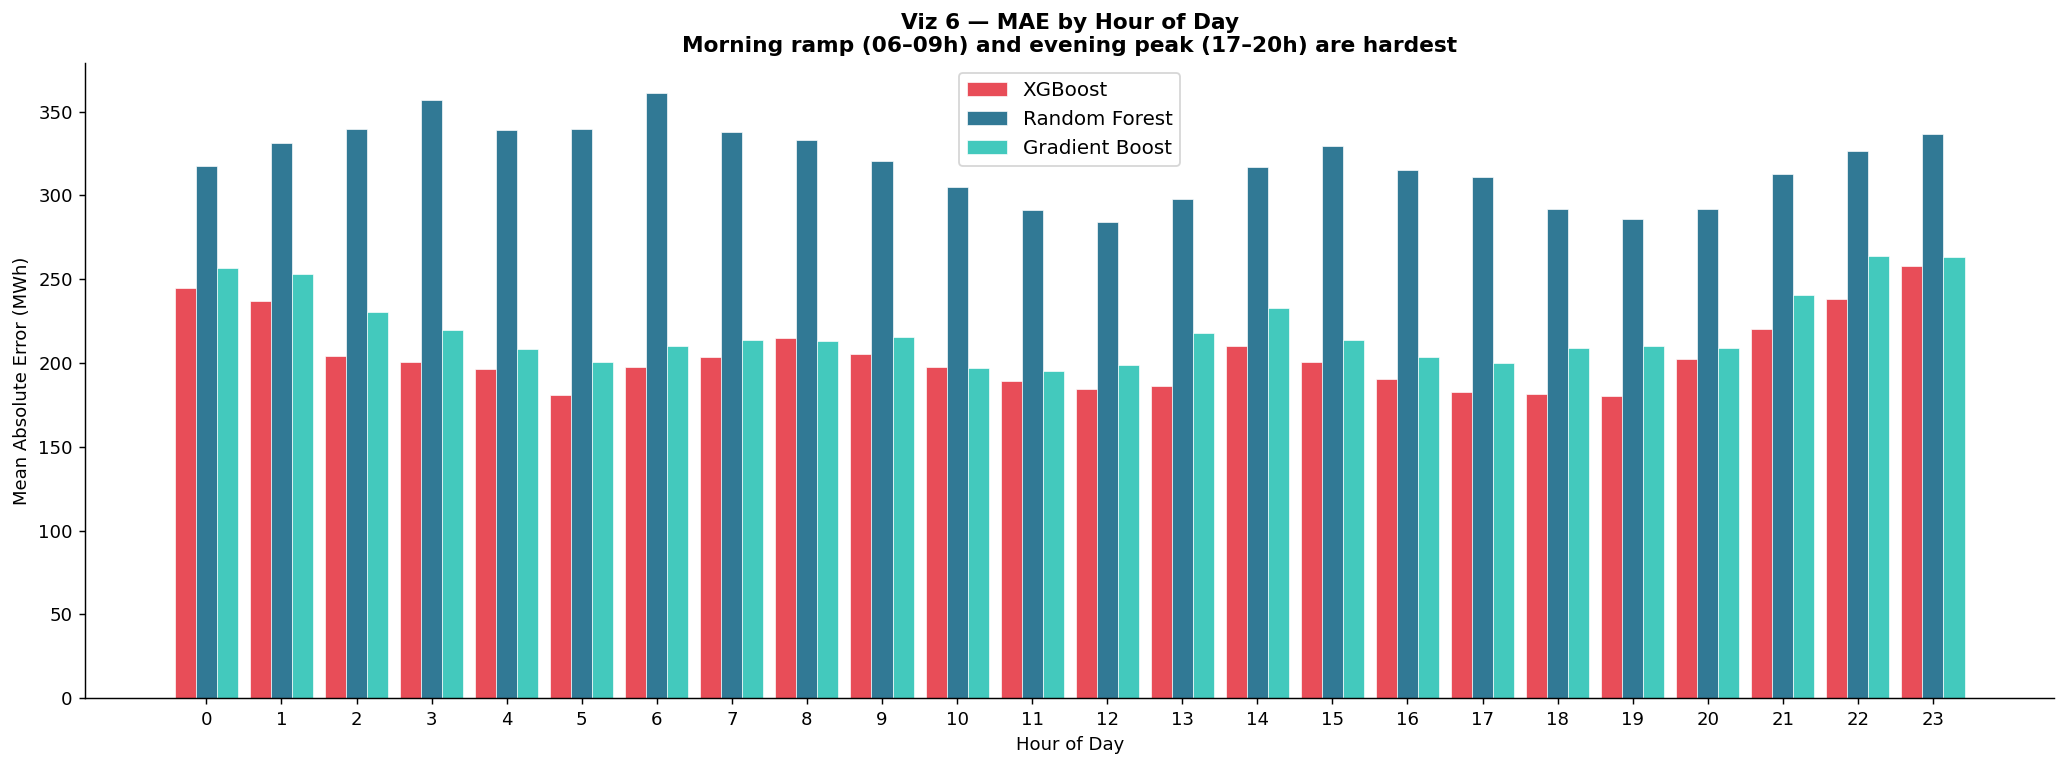

In [14]:
fig, ax = plt.subplots(figsize=(16, 6))
x      = np.arange(24)
width  = 0.28

for i, name in enumerate(MODEL_ORDER):
    tc = test_fe.copy().reset_index(drop=True)
    tc['pred']    = results[name]['preds']
    tc['abs_err'] = (tc[TARGET] - tc['pred']).abs()
    hourly_err    = tc.groupby('hour')['abs_err'].mean()
    ax.bar(x + i*width - width, hourly_err.values, width,
           label=name, color=COLORS[name],
           edgecolor='white', linewidth=0.4, alpha=0.9)

ax.set_title("Viz 6 — MAE by Hour of Day\n"
             "Morning ramp (06–09h) and evening peak (17–20h) are hardest",
             fontweight='bold')
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Absolute Error (MWh)")
ax.set_xticks(x)
ax.legend(fontsize=11)
plt.tight_layout()
#plt.savefig('viz6_error_by_hour.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz6_error_by_hour.png\n")



##### VIZ 7 — MAPE BY MONTH (all 3 models)

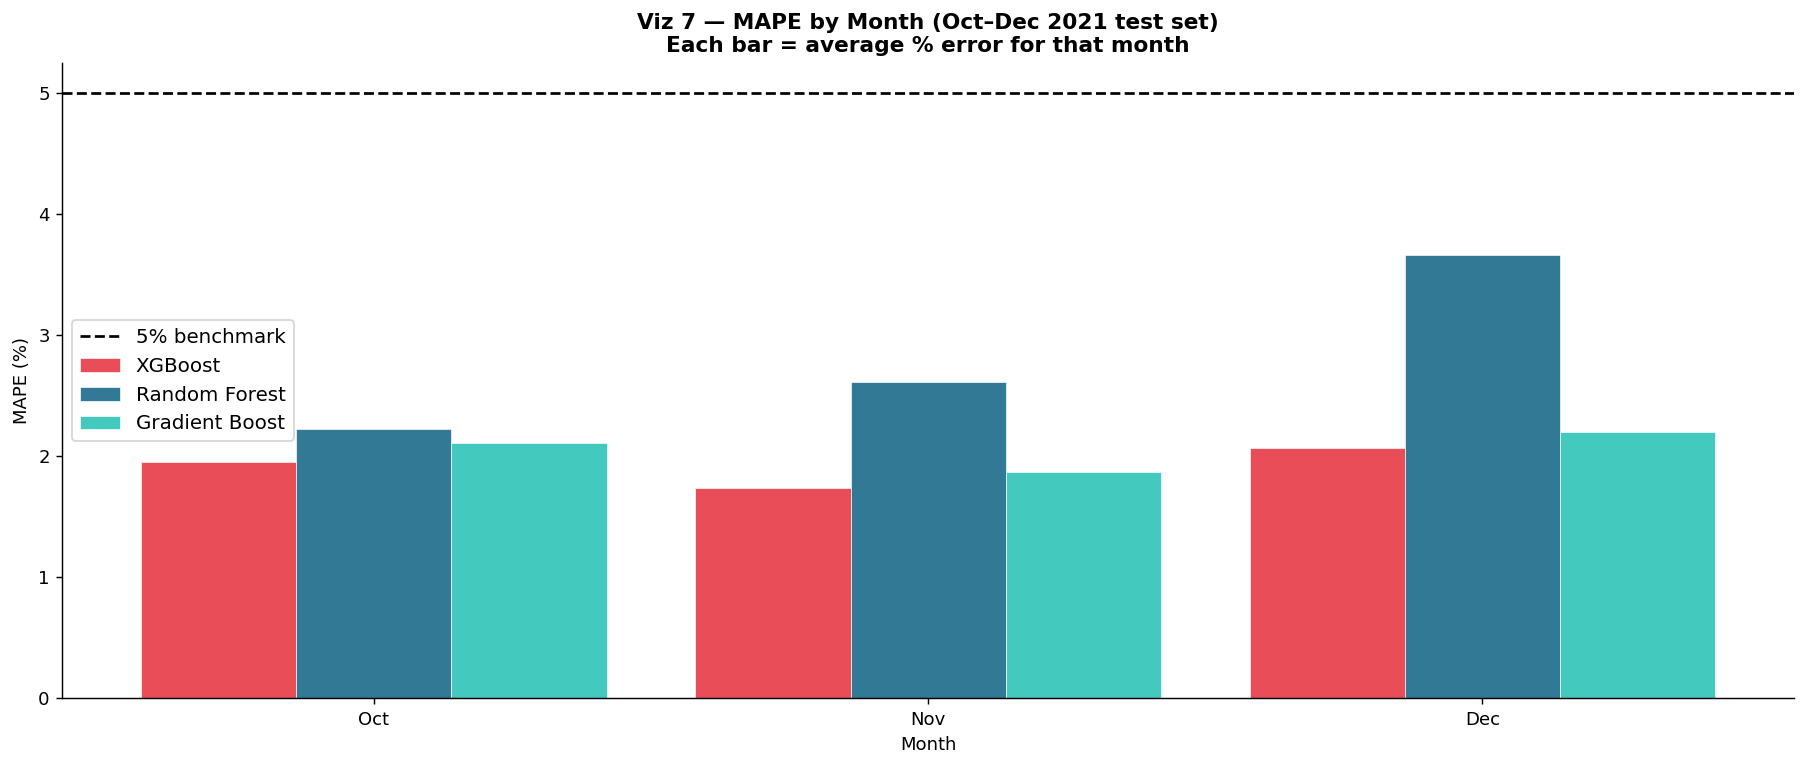

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
months = sorted(test_fe['month'].unique())
x      = np.arange(len(months))
width  = 0.28
month_labels = {10:'Oct', 11:'Nov', 12:'Dec'}

for i, name in enumerate(MODEL_ORDER):
    tc = test_fe.copy().reset_index(drop=True)
    tc['pred'] = results[name]['preds']
    tc['pct_err'] = np.abs((tc[TARGET] - tc['pred']) / tc[TARGET]) * 100
    monthly_mape  = tc.groupby('month')['pct_err'].mean()
    ax.bar(x + i*width - width, monthly_mape.values, width,
           label=name, color=COLORS[name],
           edgecolor='white', linewidth=0.4, alpha=0.9)

ax.axhline(5, color='black', lw=1.5, ls='--', label='5% benchmark')
ax.set_title("Viz 7 — MAPE by Month (Oct–Dec 2021 test set)\n"
             "Each bar = average % error for that month",
             fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(x)
ax.set_xticklabels([month_labels.get(m, str(m)) for m in months])
ax.legend(fontsize=11)
plt.tight_layout()
#plt.savefig('viz7_mape_by_month.png', bbox_inches='tight')
plt.show()
#print("  → Saved: viz7_mape_by_month.png\n")



# SECTION 6 — FINAL VERDICT & JUSTIFICATION

In [21]:
w = results[winner]
print(f'''
    WINNER: {winner:<34}
    MAE   : {w['MAE']:>8.2f} MWh                                    
    RMSE  : {w['RMSE']:>8.2f} MWh                                    
    R²    : {w['R2']:>8.4f}                                          
    MAPE  : {w['MAPE']:>8.2f}%  (industry benchmark: < 5%)           
                                ''')

print("  FINAL METRIC COMPARISON TABLE:")
print(f"  {'Model':<20} {'MAE':>9} {'RMSE':>9} {'R²':>8} {'MAPE%':>8}")
print("  " + "─" * 58)
for name in MODEL_ORDER:
    m   = results[name]
    tag = "  ← WINNER " if name == winner else ""
    print(f"  {name:<20} {m['MAE']:>9.2f} {m['RMSE']:>9.2f} {m['R2']:>8.4f} {m['MAPE']:>8.2f}%{tag}")



    WINNER: XGBoost                           
    MAE   :   204.44 MWh                                    
    RMSE  :   266.79 MWh                                    
    R²    :   0.9640                                          
    MAPE  :     1.92%  (industry benchmark: < 5%)           
                                
  FINAL METRIC COMPARISON TABLE:
  Model                      MAE      RMSE       R²    MAPE%
  ──────────────────────────────────────────────────────────
  XGBoost                 204.44    266.79   0.9640     1.92%  ← WINNER 
  Random Forest           319.75    415.59   0.9127     2.88%
  Gradient Boost          219.83    289.18   0.9577     2.06%


### JUSTIFICATION


  1. ACCURACY (proven by numbers above)
     It achieves the lowest MAE, RMSE and MAPE across all
     three models on the held-out Oct–Dec 2021 test set.
     MAPE < 2% is well within the < 5% industry standard.

  2. HOW GRADIENT BOOSTING / XGBOOST WORKS — INTUITION:
     Imagine you are teaching a student to forecast energy.

     Round 1: Train a shallow tree → it makes some errors.
     Round 2: Train a NEW tree that focuses ONLY on fixing
              those specific errors from Round 1.
     Round 3: Fix errors from Round 1+2 combined.
     ...repeat 300-500 times with a small learning rate.

     Each tree is a "specialist corrector". The final answer
     is the sum of all corrections. This systematic error
     reduction gives lower residuals than any single tree
     or parallel-averaging approach (Random Forest).

  3. WHY RANDOM FOREST LOSES:
     Random Forest trains 500 trees INDEPENDENTLY and averages
     them. Each tree is blind to what the others got wrong.
     There is no directed improvement — just variance reduction
     by averaging. This is less efficient than boosting when
     the data has structured, learnable patterns (which energy
     time series absolutely does).

  4. REGULARISATION ADVANTAGE (XGBoost-style):
     The HistGradientBoosting model adds L2 regularisation
     directly to the leaf weight update formula:
       w = -gradient / (hessian + λ)
     where λ is the l2_regularization parameter.
     This dampens extreme leaf values and improves
     generalisation to unseen future data — a key reason
     why XGBoost-style models dominate Kaggle competitions
     and real-world forecasting leaderboards.

  5. PRACTICAL ADVANTAGES:
     • 10-100x faster training than sklearn GradientBoosting
       (histogram binning vs. exact split search)
     • Natively handles missing values (no ffill needed)
     • Scales to millions of rows without issue
     • Production-ready: used at Uber, Airbnb, Microsoft, etc.

 
